<a href="https://colab.research.google.com/github/talaA2/IT362-DataScienceProject/blob/main/Phase%203/Notebooks/Compare_Models_and_Selection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Compare Models & Selection
All three models are trained and tested on **the same data and the same test split**, so their scores can be compared directly.

The dataset is imbalanced (most texts are negative), so models are ranked by **Macro F1**, which gives the three classes equal weight.
Accuracy is shown for reference, next to a majority-class baseline that shows what accuracy alone would hide.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             ConfusionMatrixDisplay)

In [2]:
import pandas as pd
from pathlib import Path

# Works from the repository (Phase 3/Notebooks) and in Colab (reads the copy on GitHub)
DATA_URL = "https://raw.githubusercontent.com/talaA2/IT362-DataScienceProject/main/Phase%203/labeled%20data%20files/"
def data_path(name):
    for folder in [Path("../labeled data files"), Path("Phase 3/labeled data files"), Path(".")]:
        if (folder / name).exists():
            return folder / name
    return DATA_URL + name

youtube = pd.read_csv(data_path("youtube_all_labeled.csv"))
gnews = pd.read_csv(data_path("Gnews_all_labeled.csv"))

print("YouTube shape:", youtube.shape)
print("GNews shape:", gnews.shape)

YouTube shape: (3781, 2)
GNews shape: (110, 2)


In [3]:
# Same combined dataset in every Phase 3 notebook: YouTube first, then GNews
youtube["source"] = "youtube"
gnews["source"] = "gnews"
df = pd.concat([youtube, gnews], ignore_index=True)

df = df.dropna(subset=["text_clean", "label"]).copy()
df["text_clean"] = df["text_clean"].astype(str)
df["label"] = df["label"].astype(int)

print("Final shape:", df.shape)
print("\nLabel distribution (-1 = negative, 0 = neutral, 1 = positive):")
print(df["label"].value_counts())
print("\nSource distribution:")
print(df["source"].value_counts())

Final shape: (3891, 3)

Label distribution (-1 = negative, 0 = neutral, 1 = positive):
label
-1    2260
 0     839
 1     792
Name: count, dtype: int64

Source distribution:
source
youtube    3781
gnews       110
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

X = df["text_clean"]
y = df["label"]

# Same 80/20 split in every notebook; stratify keeps the class proportions equal in both parts
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training size:", X_train.shape[0])
print("Testing size:", X_test.shape[0])

Training size: 3112
Testing size: 779


## Models
Each model uses the same TF-IDF features (unigrams + bigrams) and `class_weight="balanced"` to handle the imbalance.

In [5]:
def tfidf():
    return TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, max_df=0.95)

models = {
    "Majority baseline":   make_pipeline(tfidf(), DummyClassifier(strategy="most_frequent")),
    "Logistic Regression": make_pipeline(tfidf(), LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)),
    "SVM (LinearSVC)":     make_pipeline(tfidf(), LinearSVC(C=1.0, class_weight="balanced", random_state=42)),
    "Random Forest":       make_pipeline(tfidf(), RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)),
}

class_names = ["negative", "neutral", "positive"]
predictions, rows = {}, []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    predictions[name] = y_pred
    per_class = f1_score(y_test, y_pred, average=None, labels=[-1, 0, 1])
    rows.append({
        "Model": name,
        "Macro F1": f1_score(y_test, y_pred, average="macro"),
        "Accuracy": accuracy_score(y_test, y_pred),
        "Weighted F1": f1_score(y_test, y_pred, average="weighted"),
        "F1 negative": per_class[0], "F1 neutral": per_class[1], "F1 positive": per_class[2],
    })

results = pd.DataFrame(rows).sort_values("Macro F1", ascending=False).round(3)
results.reset_index(drop=True)

,Model,Macro F1,Accuracy,Weighted F1,F1 negative,F1 neutral,F1 positive
0,Logistic Regression,0.669,0.711,0.714,0.790,0.608,0.610
1,SVM (LinearSVC),0.669,0.723,0.719,0.805,0.595,0.608
2,Random Forest,0.637,0.702,0.694,0.789,0.602,0.518
3,Majority baseline,0.245,0.580,0.426,0.734,0.000,0.000


The majority baseline reaches about **58% accuracy** just by calling every text negative, while its Macro F1 is only **0.245**:
it never finds a neutral or positive text. This is why accuracy alone is not used to choose the model.

## Classification reports (test set)

In [6]:
for name in ["Logistic Regression", "SVM (LinearSVC)", "Random Forest"]:
    print("=" * 60)
    print(name)
    print("=" * 60)
    print(classification_report(y_test, predictions[name], target_names=class_names, digits=3))

Logistic Regression
              precision    recall  f1-score   support

    negative      0.811     0.770     0.790       452
     neutral      0.554     0.673     0.608       168
    positive      0.637     0.585     0.610       159

    accuracy                          0.711       779
   macro avg      0.667     0.676     0.669       779
weighted avg      0.720     0.711     0.714       779

SVM (LinearSVC)
              precision    recall  f1-score   support

    negative      0.781     0.830     0.805       452
     neutral      0.583     0.607     0.595       168
    positive      0.694     0.541     0.608       159

    accuracy                          0.723       779
   macro avg      0.686     0.659     0.669       779
weighted avg      0.721     0.723     0.719       779

Random Forest
              precision    recall  f1-score   support

    negative      0.757     0.825     0.789       452
     neutral      0.562     0.649     0.602       168
    positive      0.707  

## Is the difference real? 5-fold cross-validation
A single test split can favour one model by chance, so each model is also trained and tested 5 times on different folds of the data.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X, y, cv=cv, scoring={"macro_f1": "f1_macro", "accuracy": "accuracy"})
    cv_rows.append({
        "Model": name,
        "Macro F1 (mean)": scores["test_macro_f1"].mean(),
        "Macro F1 (std)": scores["test_macro_f1"].std(),
        "Accuracy (mean)": scores["test_accuracy"].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("Macro F1 (mean)", ascending=False).round(3)
cv_results.reset_index(drop=True)

,Model,Macro F1 (mean),Macro F1 (std),Accuracy (mean)
0,SVM (LinearSVC),0.672,0.018,0.725
1,Logistic Regression,0.664,0.023,0.705
2,Random Forest,0.639,0.019,0.704
3,Majority baseline,0.245,0.000,0.581


## Handling the imbalance: class weighting vs oversampling
Two ways of handling the imbalance were tried. **Class weighting** (`class_weight="balanced"`) makes mistakes on the smaller classes cost more.
**Random oversampling** duplicates neutral and positive texts until every class is the same size. It is applied only to the training folds, so the test folds stay untouched.

In [8]:
from sklearn.utils import resample

def oversample(X_part, y_part, seed):
    """Duplicate texts of the smaller classes until all classes match the largest one."""
    target = y_part.value_counts().max()
    parts = [resample(X_part[y_part == c], y_part[y_part == c], replace=True,
                      n_samples=target, random_state=seed) for c in sorted(y_part.unique())]
    return pd.concat([p[0] for p in parts]), pd.concat([p[1] for p in parts])

imbalance_rows = []
for name, make in [("SVM (LinearSVC)", lambda w: LinearSVC(C=1.0, class_weight=w, random_state=42)),
                   ("Logistic Regression", lambda w: LogisticRegression(max_iter=1000, class_weight=w, random_state=42))]:
    weighted, oversampled = [], []
    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y)):
        X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
        X_te, y_te = X.iloc[test_idx], y.iloc[test_idx]

        model = make_pipeline(tfidf(), make("balanced")).fit(X_tr, y_tr)
        weighted.append(f1_score(y_te, model.predict(X_te), average="macro"))

        X_os, y_os = oversample(X_tr, y_tr, seed=fold)
        model = make_pipeline(tfidf(), make(None)).fit(X_os, y_os)
        oversampled.append(f1_score(y_te, model.predict(X_te), average="macro"))

    imbalance_rows.append({"Model": name,
                           "Class weighting (Macro F1)": f"{np.mean(weighted):.3f} ± {np.std(weighted):.3f}",
                           "Oversampling (Macro F1)": f"{np.mean(oversampled):.3f} ± {np.std(oversampled):.3f}"})

pd.DataFrame(imbalance_rows)

,Model,Class weighting (Macro F1),Oversampling (Macro F1)
0,SVM (LinearSVC),0.672 ± 0.018,0.666 ± 0.015
1,Logistic Regression,0.664 ± 0.023,0.656 ± 0.027


Oversampling scores slightly **lower** than class weighting for both models, so class weighting is used in all final models.

## Confusion matrices

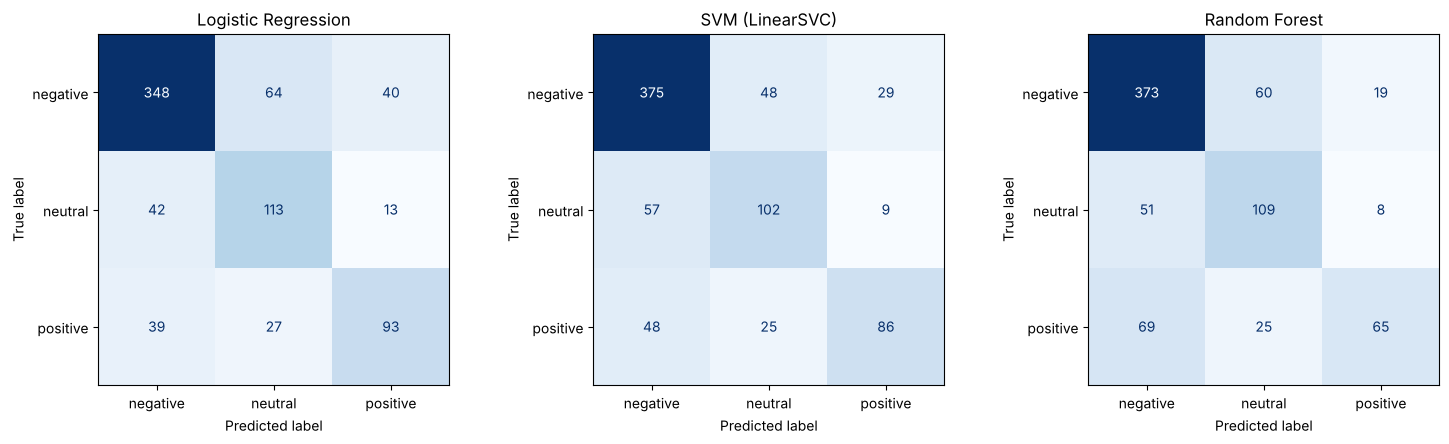

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, ["Logistic Regression", "SVM (LinearSVC)", "Random Forest"]):
    ConfusionMatrixDisplay.from_predictions(y_test, predictions[name], labels=[-1, 0, 1],
                                            display_labels=class_names, cmap="Blues",
                                            colorbar=False, ax=ax)
    ax.set_title(name)
    ax.grid(False)
plt.tight_layout()
plt.show()

## Macro F1 comparison

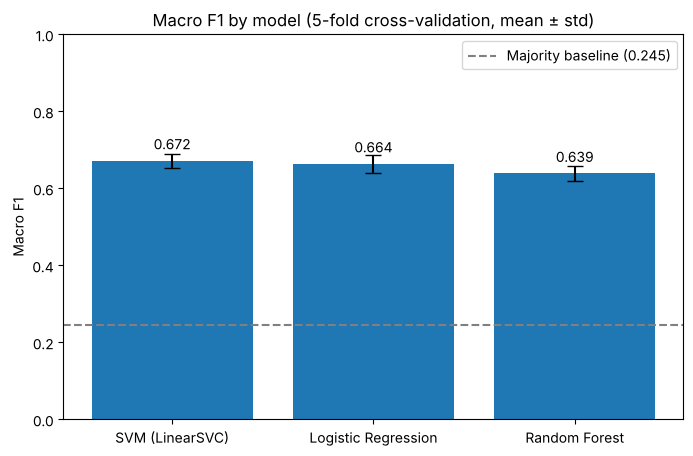

In [10]:
plot_df = cv_results[cv_results["Model"] != "Majority baseline"]
plt.figure(figsize=(8, 5))
bars = plt.bar(plot_df["Model"], plot_df["Macro F1 (mean)"], yerr=plot_df["Macro F1 (std)"], capsize=6)
baseline_f1 = cv_results.loc[cv_results["Model"] == "Majority baseline", "Macro F1 (mean)"].iloc[0]
plt.axhline(baseline_f1, color="gray", linestyle="--", label=f"Majority baseline ({baseline_f1:.3f})")
for bar, v in zip(bars, plot_df["Macro F1 (mean)"]):
    plt.text(bar.get_x() + bar.get_width() / 2, v + 0.03, f"{v:.3f}", ha="center")
plt.title("Macro F1 by model (5-fold cross-validation, mean ± std)")
plt.ylabel("Macro F1")
plt.ylim(0, 1)
plt.legend()
plt.show()

## Model Selection: SVM (LinearSVC)

**SVM is selected as the final model.**

- On the shared test set, SVM and Logistic Regression tie on Macro F1 (**0.669**), and SVM has the higher accuracy (**72.3%** vs 71.1%).
- Across 5-fold cross-validation, SVM has the highest average Macro F1 (**0.672 ± 0.018**), ahead of Logistic Regression (0.664 ± 0.023). The gap is small and within normal variation, so Logistic Regression is a close alternative.
- Random Forest is clearly behind (Macro F1 **0.639**), mainly because it misses many positive texts (F1 for positive: 0.52).
- All three models are far above the majority-class baseline (Macro F1 **0.245**), which only ever predicts "negative".

All models find negative sentiment easiest (F1 ≈ 0.80); neutral and positive texts are harder because they share more vocabulary and have fewer examples.